# Introduction

This notebook solves a version of Krusell and Smith's (1998) heterogenous-agent model with idiosyncrastic and aggregate shocks, incomplete markets and borrowing constraints. It uses a deep learning Euler-equation method introduced by Maliar, Maliar and Winant (2018) in the paper "Deep learning for solving dynamic economic models", Journal of Monetary Economics 122, pp 76-101. https://lmaliar.ws.gc.cuny.edu/files/2021/09/JME2021.pdf

This notebook shows a version of the Euler equation method that minimizes the sum of squared residuals in the equilibrium conditions. See https://deepecon.org for documentation, updates and the other versions of the deep learning method (Bellman equation and life-time reward). 

Copyright (c) 2019-2023 Marc Maliar. All rights reserved.

#### Importing required Python libraries

In [47]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import pickle
from tqdm.auto import tqdm

In [48]:
print('torch version:', torch.__version__)

torch version: 2.9.0+cpu


In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if device.type == "cuda":
    print("cuda device:", torch.cuda.get_device_name(0))


device: cpu


# Deep learning method

In [50]:
AGENTS = 50     # number of agents
LEARNING_RATE = 1e-3
TRAINING_STEPS = 30000
BATCH_SIZE = 100
DISPLAY_STEP = 1000
TRAIN_STEP_INTERVAL = 2 # Interval of steps between training episodes

# Krusell and Smith's (1998) model

The economy consists of a set of heterogeneous agents $i=1,...,\ell $ that
are identical in fundamentals but differ in productivity and capital. Each
agent $i$ solves 
\begin{gather}
\underset{\left \{ c_{t}^{i},k_{t+1}^{i}\right \} _{t=0}^{\infty }}{\max }%
E_{0}\left[ \sum_{t=0}^{\infty }\beta ^{t}u\left( {c_{t}^{i}}\right) \right]
\label{iks} \\
\text{s.t. }w_{t+1}^{i}=\left( R_{t+1}-d \right) \left( w_{t}^{i}-c_{t}^{i}\right)
+W_{t+1}\exp \left( y_{t+1}^{i}\right) ,  \label{sks} \\
c_{t}^{i}\leq w_{t}^{i},  \label{rks}
\end{gather}
where $\beta_{t}$,$c_{t}^{i}$, $w_{t}^{i}$, $y_{t}^{i}$, $R_{t}$, $W_{t}$ and $%
k_{t+1}^{i}=w_{t}^{i}-c_{t}^{i}$ are time preference, consumption, cash-on-hand, labor
productivity, interest rate, wage and next-period capital, respectively. $d\in
\left( 0,1\right] $ is the depreciation rate.
Initial condition $\left( y_{0}^{i},w_{0}^{i}\right) $ is given. The
individual productivity evolves as 
\begin{equation}
y_{t+1}^{i}=\rho _{y}y_{t}^{i}+\sigma _{y}\epsilon _{t}^{i}\text{ with }
\epsilon _{t}^{i}\sim \mathcal{N}\left( 0,1\right) .  \label{ip}
\end{equation}
The production side of the economy is described by a Cobb-Douglas production
function $z_{t}Ak_{t}^{\alpha }\left[ \sum_{i=1}^{\ell }\exp \left(
y_{t}^{i}\right) \right]$, where A is technology level, $\alpha \in \left( 0,1\right) $ and $%
z_{t}$ is an aggregate productivity shock, 
\begin{equation}
z_{t+1}=\rho_{z} z_{t}+\sigma_{z} \epsilon _{t}\text{ with }\epsilon _{t}\sim 
\mathcal{N}\left( 0,1\right) .  \label{za}
\end{equation}
Initial condition $z_{0}$ is given. The equilibrium prices are

\begin{equation}
R_{t}=
1+z_{t}\alpha Ak_{t}^{\alpha -1}\left[ \sum_{i=1}^{\ell}\exp \left(
y_{t}^{i}\right) \right] \text{ and }W_{t}=z_{t}\left( 1-\alpha \right)A
k_{t}^{\alpha }\left[ \sum_{i=1}^{\ell }\exp \left( y_{t}^{i}\right) \right],  \label{rw} 
\end{equation}


where $k_{t}=\sum_{i=1}^{\ell }k_{t}^{i}$ is aggregate capita. Note that $w_{t}^{i}=R_{t}k_{t}^{i}+W_{t}\exp \left( y_{t}^{i}\right) $. In the benchmark case, we
parametrize the model by CRRA utiltiy function, $u\left( c\right) =\frac{c^{1-\gamma }-1}{1-\gamma }
$, with a risk-aversion coefficient of $\gamma =1$. This means that the utility function is $u\left( c\right)=\ln(c)$.
We assume d=0.08, $\beta =0.96$, $%
\rho_{z} =0.95$, $\sigma_{z} =0.01$, $\rho _{y}=0.9$, and $\sigma _{y}=0.2\left(
1-\rho _{y}^{2}\right) ^{1/2}$.


# Preliminaries

#### Model parameters

In [51]:
α = 0.36   # share of capital in the Cobb-Douglas production function
d = 0.08   # depreciation rate 
A = 1      # Technology level
β = 0.96   # Time preference / discount factor
γ = 1      # parameter for risk aversion. CRRA utility function.
d = 0.08

mean_z = 0.0    # aggregate productivity shock
ρ_z = 0.9       # persistency of aggregate productivity shock
σ_z = 0.01      # standard deviation

ρ_y = 0.95      # persistency of idiosyncratic productivity
σ_y = 0.2       # standard deviation of the underlying AR(1) shock

IDIOSYNCRATIC_STATES = 14
DISASTER_STATE_INDEX = 0
DISASTER_PRODUCTIVITY = 1e-6


#### Steady state

In [52]:
K_STEADY_STATE = (((1/β)-(1-d))/α/A)**(1/(α-1))           # capital
W_STEADY_STATE = K_STEADY_STATE*(1-d)+A*K_STEADY_STATE**α # wealth 
C_STEADY_STATE = A*K_STEADY_STATE**α-d*K_STEADY_STATE     # consumption
ξ_STEADY_STATE = C_STEADY_STATE/W_STEADY_STATE            # consumption-to-wealth ratio, ksi

## Stochastic solution domain

Our economy has a wealth vector, a discrete idiosyncratic productivity-state vector, and aggregate productivity. 
The policy network sees:
- all agents' wealth,
- all agents' centered productivity-state indices,
- all agents' disaster indicators,
- aggregate productivity,
- each agent's own wealth, own centered productivity-state index, and own disaster indicator.

Aggregate productivity $z$ is still treated continuously and restricted to $\pm 2$ stationary standard deviations. 
Wealth is restricted to $[w_{\min}, w_{\max}]$. Idiosyncratic productivity follows a 7-state Rouwenhorst chain,
with the lowest state reset to the disaster value after discretization.


#### Bounds on state variables

In [53]:
# Bounds for aggregate productivity level
z_min = math.exp(-2 * σ_z / math.sqrt(1 - ρ_z**2))
z_max = math.exp(2 * σ_z / math.sqrt(1 - ρ_z**2))

# Cash-on-hand's bounds
w_min = 0.0 * W_STEADY_STATE
w_max = 4.0 * W_STEADY_STATE


#### Model functions

In [54]:
def mean_across_agents(x):
    return torch.mean(x, dim=1, keepdim=True)


def rouwenhorst_transition(num_states, p, q):
    if num_states == 1:
        return np.ones((1, 1), dtype=np.float32)

    transition = np.array([[p, 1 - p], [1 - q, q]], dtype=np.float32)
    for n in range(3, num_states + 1):
        new_transition = np.zeros((n, n), dtype=np.float32)
        new_transition[:-1, :-1] += p * transition
        new_transition[:-1, 1:] += (1 - p) * transition
        new_transition[1:, :-1] += (1 - q) * transition
        new_transition[1:, 1:] += q * transition
        new_transition[1:-1, :] /= 2.0
        transition = new_transition

    return transition


def stationary_distribution(transition):
    eigenvalues, eigenvectors = np.linalg.eig(transition.T)
    stationary_index = np.argmin(np.abs(eigenvalues - 1.0))
    stationary = np.real(eigenvectors[:, stationary_index])
    stationary = stationary / stationary.sum()
    stationary = np.maximum(stationary, 0.0)
    stationary = stationary / stationary.sum()
    return stationary.astype(np.float32)


def build_discrete_productivity_process(num_states, ρ, σ, disaster_value):
    p = (1 + ρ) / 2
    q = p
    transition = rouwenhorst_transition(num_states, p, q)

    stationary_std_log_y = σ / math.sqrt(1 - ρ**2)
    grid_half_width = stationary_std_log_y * math.sqrt(num_states - 1)
    log_y_grid = np.linspace(-grid_half_width, grid_half_width, num_states, dtype=np.float32)

    # Shift the regular states so that, absent the disaster replacement, they approximate E[y] = 1.
    log_y_grid = log_y_grid - 0.5 * stationary_std_log_y**2
    y_grid = np.exp(log_y_grid).astype(np.float32)

    # Replace the lowest state with the disaster value and rescale the remaining states
    # so that the stationary mean of productivity is still one.
    y_grid[DISASTER_STATE_INDEX] = disaster_value
    stationary_dist = stationary_distribution(transition)

    regular_mass = stationary_dist[1:].sum()
    if regular_mass <= 0:
        raise ValueError("Non-disaster states must have positive stationary mass.")

    regular_mean = float(np.dot(stationary_dist[1:], y_grid[1:]))
    target_regular_mean = 1.0 - stationary_dist[DISASTER_STATE_INDEX] * disaster_value
    scale_regular = target_regular_mean / regular_mean
    y_grid[1:] *= scale_regular

    centered_index_grid = np.arange(num_states, dtype=np.float32) - (num_states // 2)
    normalized_index_grid = centered_index_grid / np.max(np.abs(centered_index_grid))

    return (
        log_y_grid.astype(np.float32),
        y_grid.astype(np.float32),
        transition.astype(np.float32),
        stationary_dist.astype(np.float32),
        centered_index_grid.astype(np.float32),
        normalized_index_grid.astype(np.float32),
    )


(
    log_y_grid,
    y_grid,
    P_y,
    stationary_y_dist,
    centered_y_state_grid,
    normalized_y_state_grid,
) = build_discrete_productivity_process(
    num_states=IDIOSYNCRATIC_STATES,
    ρ=ρ_y,
    σ=σ_y,
    disaster_value=DISASTER_PRODUCTIVITY,
)

y_min = float(np.min(y_grid))
y_max = float(np.max(y_grid))

y_grid_t = torch.tensor(y_grid, dtype=torch.float32, device=device)
P_y_t = torch.tensor(P_y, dtype=torch.float32, device=device)
normalized_y_state_grid_t = torch.tensor(normalized_y_state_grid, dtype=torch.float32, device=device)


def productivity_level_from_index(y_idx):
    return y_grid_t[y_idx]


def sample_next_productivity_index(y_idx):
    transition_rows = P_y_t[y_idx]
    transition_rows_flat = transition_rows.reshape(-1, IDIOSYNCRATIC_STATES)
    y_idxp = torch.multinomial(transition_rows_flat, num_samples=1, replacement=True)
    y_idxp = y_idxp.reshape_as(y_idx)
    return y_idxp.long()


def consumption_capital(w, ξ):
    c = w * ξ
    kp = w * (1 - ξ)              # k' = next-period individual capital
    kp = torch.clamp(kp, max=w_max)
        # if kp > W_HIGH, set kp = W_HIGH
    c = w - kp
        # recompute c

    return c, kp


def next_period(kp, yp, zp):
    kp_aggregate = mean_across_agents(kp)
    rp = A * zp * α * kp_aggregate**(α - 1)       # next-period interest rate
    wagep = A * zp * (1 - α) * kp_aggregate**α   # next-period wage
    wp = (1 - d + rp) * kp + wagep * yp          # individual next-period wealth

    return rp, wp


def productivity_transition_to_next_period(y_idx, z, εz):
    y_idxp = sample_next_productivity_index(y_idx)
    yp = productivity_level_from_index(y_idxp)

    zp = z**ρ_z * torch.exp(εz) * math.exp((-0.5 * (1 - ρ_z) * σ_z**2) / (1 - ρ_z**2))
    zp = torch.clamp(zp, min=z_min, max=z_max)
        # aggregate productivity remains continuous

    return y_idxp, yp, zp


def normalize_all(w, y_idx, z):
    # normalize inputs for neural network
    normw = (w - w_min) / (w_max - w_min) * 2.0 - 1.0
        # normalize to interval [-1,1]
    normy_idx = normalized_y_state_grid_t[y_idx]
        # centered and standardized discrete productivity-state index
    normz = torch.log(z) / (2 * σ_z / math.sqrt(1 - ρ_z**2))
    disaster_state = (y_idx == DISASTER_STATE_INDEX).to(torch.float32)
        # separate binary input because the disaster state is not symmetric with the regular grid

    return normw, normy_idx, normz, disaster_state


# The neural-network

#### Parameterization of decision functions with neural networks

We parametrize the consumption to
wealth ratio $\frac{c_{t}^{i}}{w_{t}^{i}}$ and unit-free Lagrange multiplier $%
h_{t}^{i}$:
\begin{eqnarray*}
\xi_t=\frac{c_{t}^{i}}{w_{t}^{i}} &=&\sigma \left( \zeta _{0}+\eta \left(
y_{t}^{i},w_{t}^{i},D_{t},z_{t};\vartheta \right) \right) \equiv \varphi
\left( \cdot ;\theta \right), \\
h_{t}^{i} &=&\exp \left( \zeta _{0}+\eta \left(
y_{t}^{i},w_{t}^{i},D_{t},z_{t};\vartheta \right) \right) \equiv h\left(
\cdot ;\theta \right), 
\end{eqnarray*}
where $\eta \left( \cdot ;\vartheta \right) $ is a neural network, $%
D_{t}\equiv \left \{ y_{t}^{i},w_{t}^{i}\right \} _{i=1}^{\ell }$ is the
distribution, $\theta \equiv \left( \zeta _{0},\vartheta \right) $ and $%
\sigma \left( x\right) =\frac{1}{1+e^{-x}}$.

A sigmoid transformation of $\varphi \left( \cdot ;\theta \right) $ ensures
that $\frac{c_{t}^{i}}{w_{t}^{i}}$ is in the interval $\left[ 0,1\right] $;
the exponentiation of $h_{t}$ ensures that it is nonnegative. The parameter $%
\zeta _{0}$s are calibrated; $\zeta _{0}=logit(\frac{c_{steady\_state}}{w_{steady\_state}})$ for $\varphi
\left( \cdot ;\theta \right)$ and $\zeta _{0}=0$ for $h\left(
\cdot ;\theta \right)$.
The biases and weights are initialized
randomly by using "he" and "glorot" uniform distributions,
respectively. In the baseline case, we use a neural network with a sigmoid
activation function and two hidden layers of $32\times 32$ neurons.

#### Architecture

In [55]:
input_dimension = 3 * AGENTS + 4    # inputs consist of 
                                    # 3*AGENTS common state variables of all agents:
                                    # wealth, standardized productivity-state index, disaster indicator
                                    # 3 own state variables of a given agent i
                                    # 1 aggregate productivity
first_hidden_layer_neurons = 32
second_hidden_layer_neurons = 32
output_dimension = 2                # ksi (share of consumption in wealth), multiplier (on the borrowing constraint)


#### Resulting layer shapes (weights and biases)

In [56]:
first_hidden_layer_weights_shape = \
    (input_dimension,             first_hidden_layer_neurons)
# E.g., with 10 agents and 4 neurons, it's 23-by-4, where input_dimension = 23 with 10 agents
first_hidden_layer_biases_shape  = \
    (1,                           first_hidden_layer_neurons)

second_hidden_layer_weights_shape = \
    (first_hidden_layer_neurons,  second_hidden_layer_neurons)
# E.g., 4 neurons in each hidden leayer, it's 4-by-4
second_hidden_layer_biases_shape  = \
    (1,                           second_hidden_layer_neurons)

output_layer_weights_shape = \
    (second_hidden_layer_neurons, output_dimension)
output_layer_biases_shape  = \
    (1,                           output_dimension)

#### Creating the neural-network in PyTorch

In [57]:
class PolicyNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(input_dimension, first_hidden_layer_neurons)
        self.fc2 = nn.Linear(first_hidden_layer_neurons, second_hidden_layer_neurons)
        self.fc_out = nn.Linear(second_hidden_layer_neurons, output_dimension)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.trunc_normal_(self.fc1.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.fc1.bias)

        nn.init.trunc_normal_(self.fc2.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.fc2.bias)

        nn.init.trunc_normal_(self.fc_out.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.fc_out.bias)

    def forward(self, input_tensor):
        x = torch.sigmoid(self.fc1(input_tensor))
        x = torch.sigmoid(self.fc2(x))
        x = self.fc_out(x)

        # Don’t apply sigmoid to the last layer, we will do it later if necessary
        return x


policy_net = PolicyNetwork().to(device)

In [58]:
trainable_variables_list = list(policy_net.parameters())  # list of trainable neural network parameters

#### The neural-network function

In [59]:
def neural_network(input_tensor):
    return policy_net(input_tensor)

#### NN functions that produce decision variables

In [60]:
def run_neural_network_for_all_agents_given_state(w, y_idx, z):

    # Normalize the states used in the neural network
    normw, normy_idx, normz, disaster_state = normalize_all(w, y_idx, z)

    common_information = torch.cat([normw, normy_idx, disaster_state], dim=1)
    common_information = common_information.unsqueeze(1).expand(-1, AGENTS, -1)
        # Batches, agents, 3*AGENTS

    aggregate_productivity = normz.unsqueeze(1).expand(-1, AGENTS, -1)
        # Batches, agents, 1

    own_information = torch.stack([normw, normy_idx, disaster_state], dim=2)
        # Batches, agents, 3

    input_tensor = torch.cat(
        [common_information, aggregate_productivity, own_information], dim=2
    )
    input_tensor = input_tensor.reshape(-1, input_dimension)
        # Batches * agents, input_dimension

    output_tensor = neural_network(input_tensor)
        # Batches * agents, output_dimension

    output_tensor_reshaped = output_tensor.reshape(-1, AGENTS, output_dimension)

    ξ_before_sigmoid, μ_before_exp = torch.unbind(output_tensor_reshaped, dim=2)

    def logit(x):
        return np.log(x / (1 - x))  # Inverse of sigmoid

    ξ = torch.sigmoid(ξ_before_sigmoid + logit(ξ_STEADY_STATE))  # KSI
    μ = torch.exp(μ_before_exp)  # Lagrangian multiplier

    return ξ, μ
        # given state variables, we get ksi (share of consumption in wealth), multiplier (on the borrowing constraint)


# Define the model in PyTorch

#### Euler objective function for training

Our Euler objective function for Krusell and Smith's (1998) model is
based on the all-in-one expectation operator of two uncorrelated future draws.

In this notebook, aggregate productivity $z$ remains continuous, while idiosyncratic productivity is a 7-state Markov chain built from Rouwenhorst's method.
The lowest idiosyncratic state is reset to a disaster value after discretization, and the policy network is conditioned on the centered discrete-state index plus a separate disaster indicator.


#### Apply model functions in PyTorch

In [61]:
def run_model(w0, y_idx0, z0, εz_a, εz_b):

    ξ0, μ0 = run_neural_network_for_all_agents_given_state(w0, y_idx0, z0)
    c0, k1 = consumption_capital(w0, ξ0)

    y_idx1_a, y1_a, z1_a = productivity_transition_to_next_period(y_idx0, z0, εz_a)
    r1_a, w1_a = next_period(k1, y1_a, z1_a)
    ξ1_a, μ1_a = run_neural_network_for_all_agents_given_state(w1_a, y_idx1_a, z1_a)
    c1_a, k2_a = consumption_capital(w1_a, ξ1_a)

    y_idx1_b, y1_b, z1_b = productivity_transition_to_next_period(y_idx0, z0, εz_b)
    r1_b, w1_b = next_period(k1, y1_b, z1_b)
    ξ1_b, μ1_b = run_neural_network_for_all_agents_given_state(w1_b, y_idx1_b, z1_b)
    c1_b, k2_b = consumption_capital(w1_b, ξ1_b)

    # Error 1
    R_μ = μ0 - 1
    R_ξ = w0 / c0 - 1
    R_μξ = R_μ + R_ξ - torch.sqrt(R_μ**2 + R_ξ**2)
        # residual in the Fisher-Burmeister function; eq. (25) in MMV (2021)

    # Error 2
    R2_a = β * (c1_a**(-γ)) * (1 - d + r1_a) / (c0**(-γ)) - μ0
        # residual in the Euler equation under shock a
    R2_b = β * (c1_b**(-γ)) * (1 - d + r1_b) / (c0**(-γ)) - μ0

    Residual1 = torch.mean(R_μξ**2)
    Residual2 = torch.mean(R2_a * R2_b)

    # Mean squared errors
    loss_op = Residual1 + Residual2

    return (
        ξ0, μ0, c0, k1,
        y_idx1_a, y1_a, z1_a, r1_a, w1_a, ξ1_a, μ1_a, c1_a, k2_a,
        y_idx1_b, y1_b, z1_b, r1_b, w1_b, ξ1_b, μ1_b, c1_b, k2_b,
        loss_op, Residual1, Residual2,
    )


# Training

#### Make empty loss-value vector

In [62]:
loss_vals = np.empty((TRAINING_STEPS, 1)) # Return a new array of size TRAINING_STEPS-by-1

#### Optimizer

In [63]:
# Define the optimization method to be used
optimizer = optim.Adam(trainable_variables_list, lr=LEARNING_RATE)

#### Functions used to generate shocks and initial states

#### Functions used to generate shocks

In [64]:
def initial_state(required_batch_size):
    w = np.reshape(
        np.random.uniform(W_STEADY_STATE, W_STEADY_STATE, required_batch_size * AGENTS),
        (required_batch_size, AGENTS),
    )
    y_idx = np.full(
        (required_batch_size, AGENTS),
        IDIOSYNCRATIC_STATES // 2,
        dtype=np.int64,
    )
    z = np.reshape(
        np.random.uniform(1, 1, required_batch_size),
        (required_batch_size, 1),
    )
    w = torch.tensor(w, dtype=torch.float32, device=device)
    y_idx = torch.tensor(y_idx, dtype=torch.long, device=device)
    z = torch.tensor(z, dtype=torch.float32, device=device)
    return w, y_idx, z
        # initial condition is taken in the steady state / center productivity state


def generate_εz(required_batch_size):
    return torch.tensor(
        np.reshape(
            np.random.normal(mean_z, σ_z, required_batch_size),
            (required_batch_size, 1),
        ),
        dtype=torch.float32,
        device=device,
    )
        # generate shocks to z


#### Training

In [65]:
# Start timer
start = time.time()

# initial states
w_train, y_idx_train, z_train = initial_state(required_batch_size=BATCH_SIZE)
    # construct initial condition in the steady state

training_pbar = tqdm(range(TRAINING_STEPS), desc="Training", total=TRAINING_STEPS)

for i in training_pbar:
    # Get 2 uncorrelated aggregate shocks. The two idiosyncratic draws are sampled
    # inside run_model from the discrete Markov chain.
    εz_a_train = generate_εz(BATCH_SIZE)
    εz_b_train = generate_εz(BATCH_SIZE)

    # Train the model if the remainder of i/TRAIN_STEP_INTERVAL == 0
    if i % TRAIN_STEP_INTERVAL == 0:
        optimizer.zero_grad()
        outputs = run_model(
            w0=w_train,
            y_idx0=y_idx_train,
            z0=z_train,
            εz_a=εz_a_train,
            εz_b=εz_b_train,
        )
        loss_op = outputs[-3]
        Residual1 = outputs[-2]
        Residual2 = outputs[-1]
        w1_a = outputs[8]
        y_idx1_a = outputs[4]
        z1_a = outputs[6]

        loss_op.backward()
        optimizer.step()

    # Just run the model if the remainder of i/TRAIN_STEP_INTERVAL != 0
    else:
        with torch.no_grad():
            outputs = run_model(
                w0=w_train,
                y_idx0=y_idx_train,
                z0=z_train,
                εz_a=εz_a_train,
                εz_b=εz_b_train,
            )
            loss_op = outputs[-3]
            Residual1 = outputs[-2]
            Residual2 = outputs[-1]
            w1_a = outputs[8]
            y_idx1_a = outputs[4]
            z1_a = outputs[6]

    loss_vals[i] = loss_op.detach().cpu().item()

    w_train = w1_a.detach()
    y_idx_train = y_idx1_a.detach()
    z_train = z1_a.detach()

    # Update the progress bar periodically
    if i % DISPLAY_STEP == 0 or i == TRAINING_STEPS - 1:
        training_pbar.set_postfix(
            loss=f"{loss_op.detach().cpu().item():.3e}",
            R1=f"{Residual1.detach().cpu().item():.3e}",
            R2=f"{Residual2.detach().cpu().item():.3e}",
        )

# Stop timer
time_elapsed = time.time() - start

print("Training took", time_elapsed, "seconds.")

Training:   0%|          | 0/30000 [00:00<?, ?it/s]

Training took 434.79551243782043 seconds.


# Decision-rule plot run

In [66]:
# Make a plot of decision rules
DECISION_RULE_PLOT_POINTS = 100
DECISION_RULE_Y_REALIZATIONS = IDIOSYNCRATIC_STATES

def dim(x, i):  # Add dimension to x at axis i helper function
    return np.expand_dims(x, axis=i)

# Use the first batch
batch_number = 0
w = w_train[batch_number].detach().cpu().numpy()
y_idx = y_idx_train[batch_number].detach().cpu().numpy()
z = z_train[batch_number].detach().cpu().numpy()

# Repeat k for all plot points
w = np.repeat(dim(dim(w, 0), 0), DECISION_RULE_PLOT_POINTS, axis=0)
# Set the first agent's wealth to evenly spaced values between w_min and w_max
w[:, :, 0] = dim(np.linspace(w_min, w_max, DECISION_RULE_PLOT_POINTS), 1)
# Repeat k for all productivity realizations
w = np.repeat(w, DECISION_RULE_Y_REALIZATIONS, axis=1)

# Repeat productivity-state indices for all realizations
y_idx = np.repeat(dim(y_idx, 0), DECISION_RULE_Y_REALIZATIONS, axis=0)
# Set the first agent's productivity state to each discrete state
y_idx[:, 0] = np.arange(IDIOSYNCRATIC_STATES)

# Repeat aggregate productivity for all realizations
z = np.repeat(dim(z, 0), DECISION_RULE_Y_REALIZATIONS, axis=0)

# Will store our results
decision_rule_results = {
    "w0": np.empty(shape=(DECISION_RULE_PLOT_POINTS, DECISION_RULE_Y_REALIZATIONS, AGENTS)),
    "w1": np.empty(shape=(DECISION_RULE_PLOT_POINTS, DECISION_RULE_Y_REALIZATIONS, AGENTS)),
    "c0": np.empty(shape=(DECISION_RULE_PLOT_POINTS, DECISION_RULE_Y_REALIZATIONS, AGENTS)),
    "k1": np.empty(shape=(DECISION_RULE_PLOT_POINTS, DECISION_RULE_Y_REALIZATIONS, AGENTS)),
}


def generate_εz_constant(required_batch_size):
    return torch.zeros((required_batch_size, 1), dtype=torch.float32, device=device)


for step in tqdm(range(DECISION_RULE_PLOT_POINTS), desc="Decision-rule grid", total=DECISION_RULE_PLOT_POINTS):
    εz_a = generate_εz_constant(DECISION_RULE_Y_REALIZATIONS)

    with torch.no_grad():
        outputs = run_model(
            w0=torch.tensor(w[step], dtype=torch.float32, device=device),
            y_idx0=torch.tensor(y_idx, dtype=torch.long, device=device),
            z0=torch.tensor(z, dtype=torch.float32, device=device),
            εz_a=εz_a,
            εz_b=εz_a,
        )
        c0 = outputs[2]
        k1 = outputs[3]
        w1_a = outputs[8]

    # Save it
    decision_rule_results["w0"][step] = w[step]
    decision_rule_results["w1"][step] = w1_a.detach().cpu().numpy()
    decision_rule_results["c0"][step] = c0.detach().cpu().numpy()
    decision_rule_results["k1"][step] = k1.detach().cpu().numpy()


Decision-rule grid:   0%|          | 0/100 [00:00<?, ?it/s]

# Simulation plot run

In [67]:
SIMULATION_BATCH_SIZE = 1  # BATCH_SIZE
SIMULATION_TIME_PERIODS = 1000

# Take only as many as we need
w = w_train[:SIMULATION_BATCH_SIZE].detach().clone()
y_idx = y_idx_train[:SIMULATION_BATCH_SIZE].detach().clone()
z = z_train[:SIMULATION_BATCH_SIZE].detach().clone()


def generate_εz_numpy(required_batch_size):
    return np.reshape(
        np.random.normal(mean_z, σ_z, required_batch_size),
        (required_batch_size, 1),
    )
        # generate shocks to z


# Restore aggregate shocks from file if available
try:
    with open("one.pkl", "rb") as f:
        restored_shocks = pickle.load(f)
except Exception:
    restored_shocks = {
        "εz": np.random.normal(0, 1, size=(SIMULATION_TIME_PERIODS, 1)),
    }

restored_εz = restored_shocks.get("εz", np.random.normal(0, 1, size=(SIMULATION_TIME_PERIODS, 1)))[:, :1] * σ_z + mean_z

simulation_results = {  # Initial place where we will put results
    "k": np.empty(shape=(SIMULATION_TIME_PERIODS, SIMULATION_BATCH_SIZE, AGENTS)),
    "c": np.empty(shape=(SIMULATION_TIME_PERIODS, SIMULATION_BATCH_SIZE, AGENTS)),
    "w": np.empty(shape=(SIMULATION_TIME_PERIODS, SIMULATION_BATCH_SIZE, AGENTS)),
    "y_idx": np.empty(shape=(SIMULATION_TIME_PERIODS, SIMULATION_BATCH_SIZE, AGENTS), dtype=np.int64),
    "y": np.empty(shape=(SIMULATION_TIME_PERIODS, SIMULATION_BATCH_SIZE, AGENTS)),
    "z": np.empty(shape=(SIMULATION_TIME_PERIODS, SIMULATION_BATCH_SIZE, 1)),
}

for step in tqdm(range(SIMULATION_TIME_PERIODS), desc="Simulation", total=SIMULATION_TIME_PERIODS):
    # Generate aggregate shocks
    εz_simulation = generate_εz_numpy(SIMULATION_BATCH_SIZE)

    # For batch zero, use shocks provided in file
    εz_simulation[0] = restored_εz[step]

    εz_simulation = torch.tensor(εz_simulation, dtype=torch.float32, device=device)

    w0 = w
    y_idx0 = y_idx
    y0 = productivity_level_from_index(y_idx0)
    z0 = z

    with torch.no_grad():
        outputs = run_model(
            w0=w0,
            y_idx0=y_idx0,
            z0=z0,
            εz_a=εz_simulation,
            εz_b=εz_simulation,
        )
        c0 = outputs[2]
        k1 = outputs[3]
        y_idx1_a = outputs[4]
        z1_a = outputs[6]
        w1_a = outputs[8]

    # Save it
    simulation_results["k"][step] = k1.detach().cpu().numpy()
    simulation_results["c"][step] = c0.detach().cpu().numpy()
    simulation_results["w"][step] = w0.detach().cpu().numpy()
    simulation_results["y_idx"][step] = y_idx0.detach().cpu().numpy()
    simulation_results["y"][step] = y0.detach().cpu().numpy()
    simulation_results["z"][step] = z0.detach().cpu().numpy()

    # Transition
    w = w1_a.detach()
    y_idx = y_idx1_a.detach()
    z = z1_a.detach()


Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

# Plotting

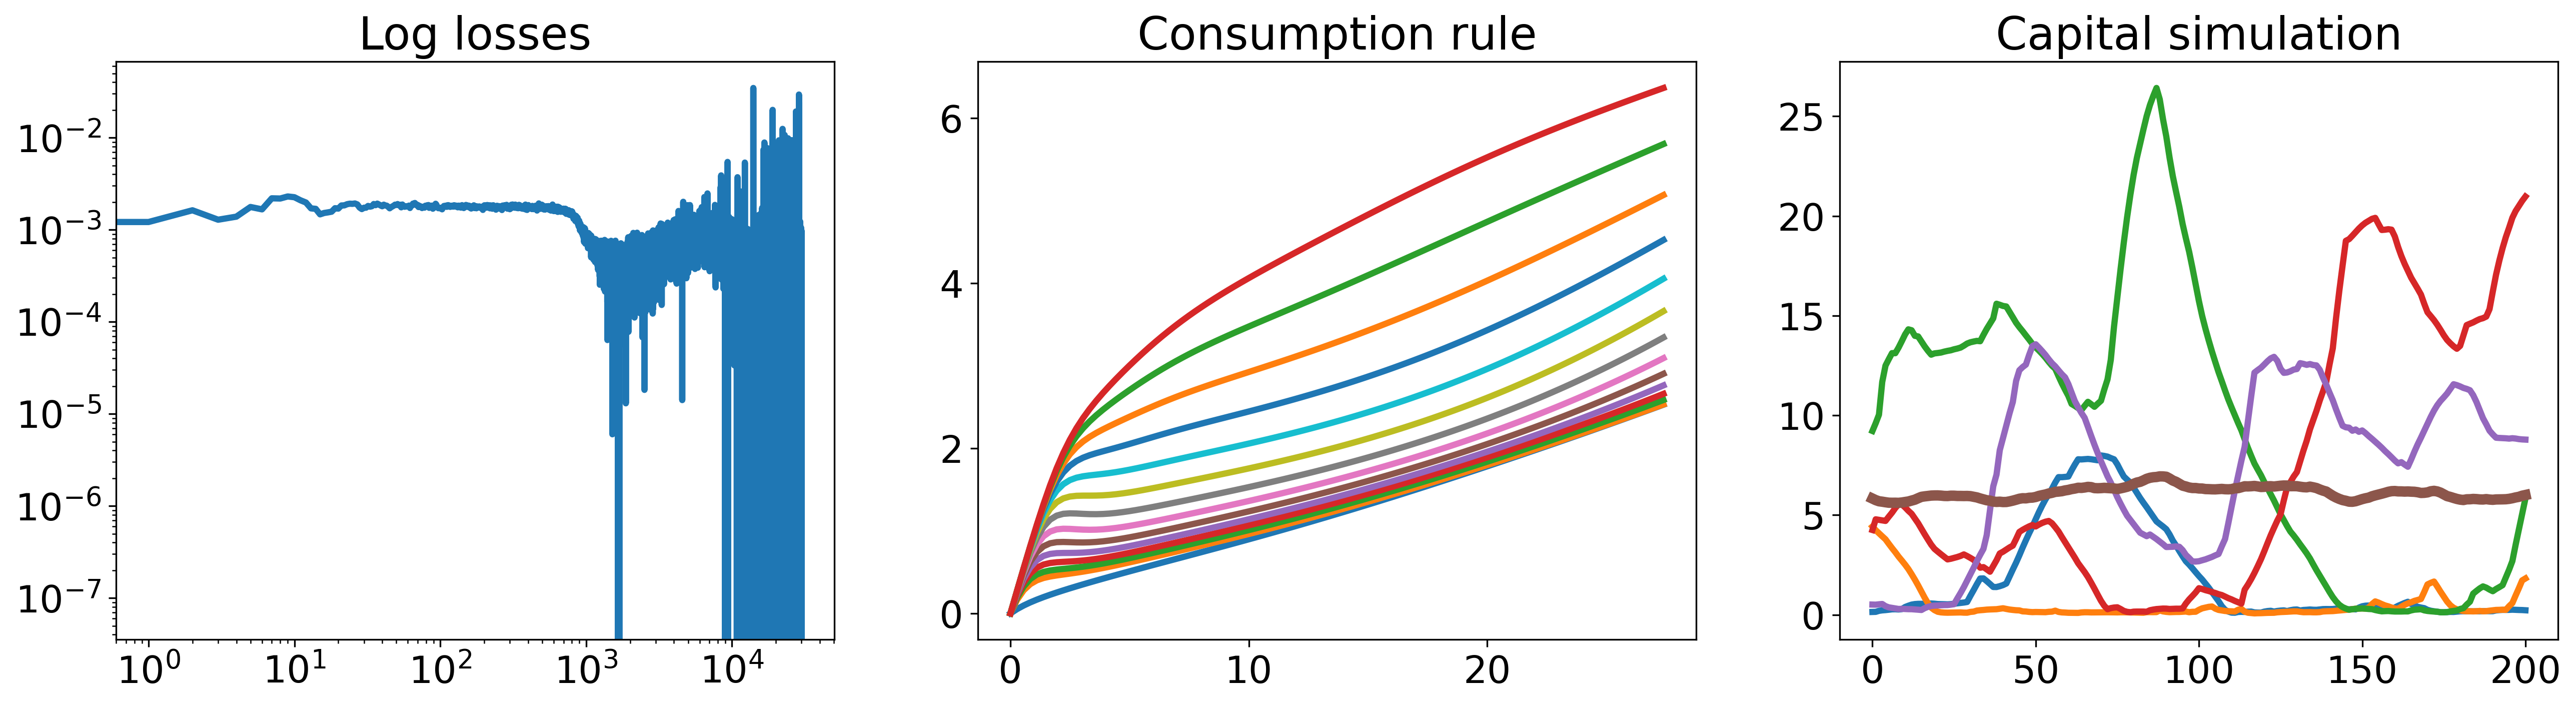

In [68]:
# Set plotting parameters
plt.rcParams['agg.path.chunksize'] = 100000
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 18

# Columns and rows in graph
rows = 1
cols = 3

# Width, height automatically set
height = 5 * rows
width = 7 * cols

fig = plt.figure()
fig.set_figwidth(width)
fig.set_figheight(height)

# Plot learning losses
ax = plt.subplot(rows, cols, 1)
_ = plt.plot(loss_vals)
plt.yscale('log')
plt.xscale('log')
ax.title.set_text("Log losses")

ax = plt.subplot(rows, cols, 2)
for i in range(decision_rule_results["c0"].shape[1]):
    plt.plot(decision_rule_results["w0"][:, i, 0], decision_rule_results["c0"][:, i, 0])
ax.title.set_text("Consumption rule")

ax = plt.subplot(rows, cols, 3)
start = 200
end = 400
drawn_agents = 5
for i in range(min(drawn_agents, simulation_results["k"].shape[2])):
    plt.plot(simulation_results["k"][start:end + 1, 0, i])  # draw only batch n = 0
if simulation_results["k"].shape[2] != 1:
    plt.plot(
        np.mean(simulation_results["k"][start:end + 1, 0], axis=1),
        linewidth=5.0,
    )
ax.title.set_text("Capital simulation")

save_paths = ['./figures/newFigure.png', '../../figures/newFigure.png']
for save_path in save_paths:
    directory = os.path.dirname(save_path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    try:
        plt.savefig(save_path, bbox_inches='tight')
        break
    except OSError:
        continue

# If it doesn't show up, open it manually in the figures directory
plt.show()

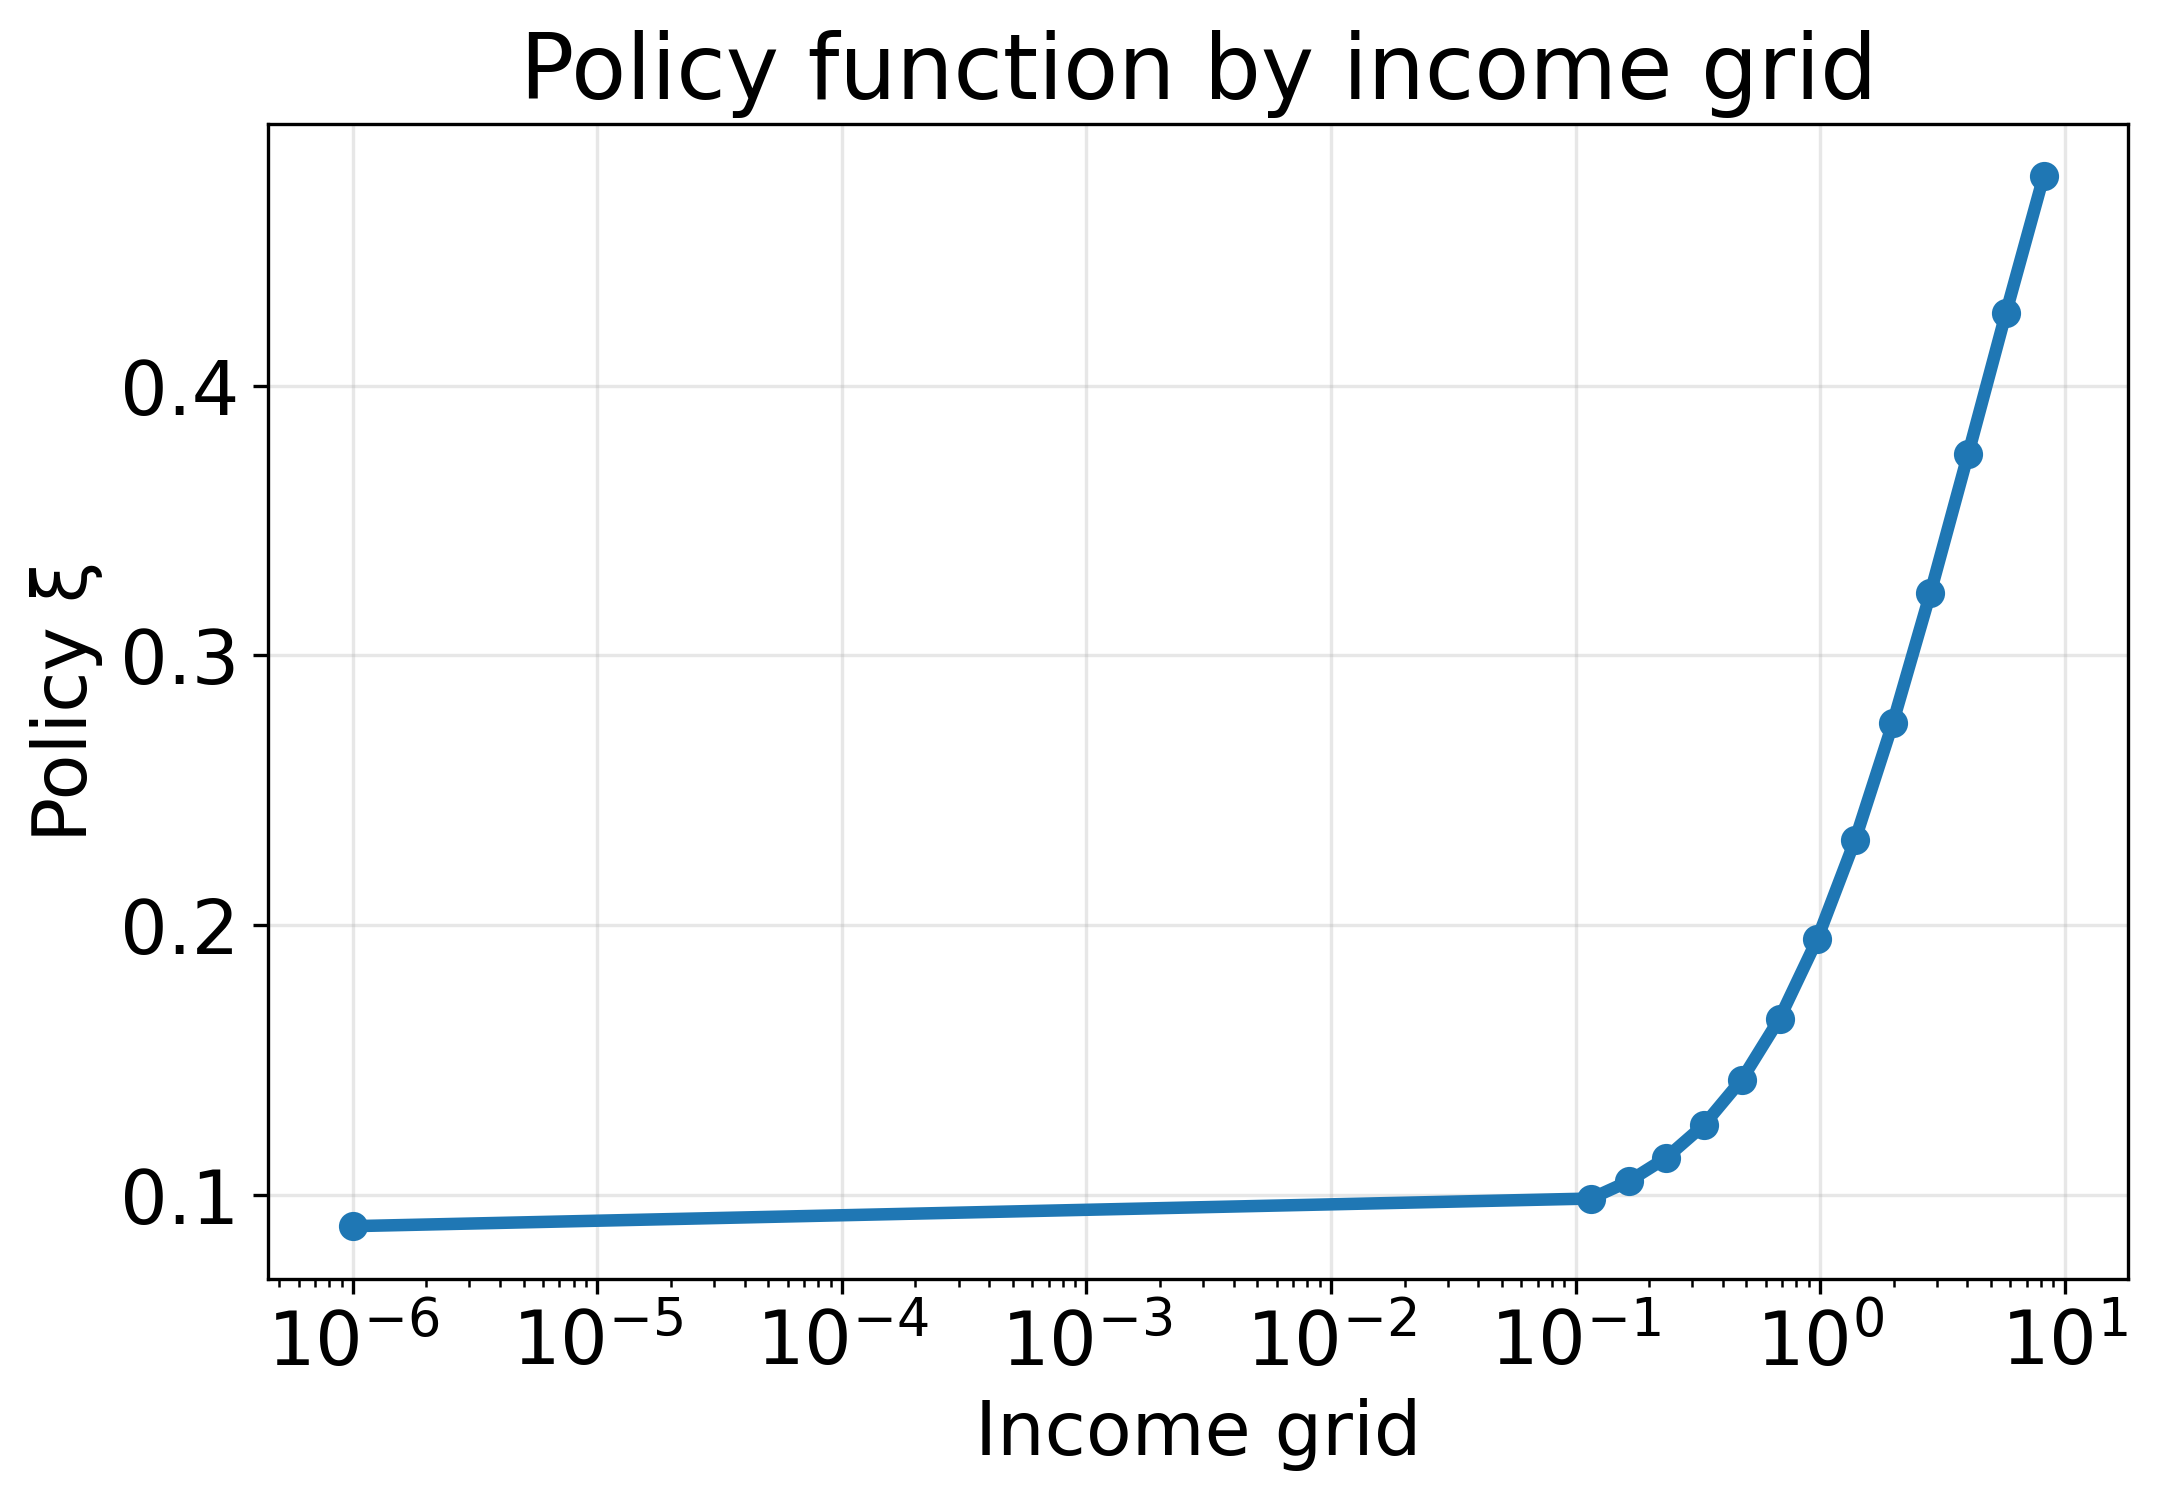

In [69]:
# Plot the policy function against the income grid
z_val = torch.tensor([[1.0]], dtype=torch.float32, device=device)
w_val = torch.full((1, AGENTS), W_STEADY_STATE, dtype=torch.float32, device=device)

income_grid = np.asarray(y_grid, dtype=np.float32)
policy_vals = np.empty_like(income_grid)

for idx in range(IDIOSYNCRATIC_STATES):
    y_idx_val = torch.full((1, AGENTS), idx, dtype=torch.long, device=device)

    with torch.no_grad():
        ξ_val, _ = run_neural_network_for_all_agents_given_state(w_val, y_idx_val, z_val)

    policy_vals[idx] = ξ_val[0, 0].item()

sort_idx = np.argsort(income_grid)
income_grid_plot = income_grid[sort_idx]
policy_vals_plot = policy_vals[sort_idx]

plt.figure(figsize=(8, 5))
plt.plot(income_grid_plot, policy_vals_plot, marker='o')
plt.xscale('log')
plt.title("Policy function by income grid")
plt.xlabel("Income grid")
plt.ylabel("Policy ξ")
plt.grid(True, alpha=0.3)
plt.show()